# Dataset3: Synthetic Data Generation

Synthetic dataset generated from `dataset2_processed.csv` using a **Gaussian Copula** approach, which preserves:
- marginal distributions of all features
- inter-feature correlations
- categorical class balance

In [4]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import QuantileTransformer

warnings.filterwarnings("ignore")

INPUT_PATH  = "../data/processed/dataset2_processed.csv"   
OUTPUT_PATH = "../data/synthetic_dataset3.csv"    
N_SAMPLES   = None   
SEED        = 42

CATEGORICAL_COLS = {
    "patient_cc": [0.0, 1.0, 2.0],
    "sample_o":   [0.0, 1.0, 2.0],
    "sex":        [0.0, 1.0],
    "diagnosis":  [1.0, 2.0, 3.0],
}
CONTINUOUS_COLS = [
    "plasma_C", "creatinine", "LYVE1", "REG1B", "TFF1",
    "REG1A", "CA19_9", "CEA", "bilirubin", "glucose",
    "urine_volume", "urine_pH",
]
AGE_COL = "age"
ALL_COLS = [
    "patient_cc", "sample_o", "age", "sex", "diagnosis",
    "plasma_C", "creatinine", "LYVE1", "REG1B", "TFF1",
    "REG1A", "CA19_9", "CEA", "bilirubin", "glucose",
    "urine_volume", "urine_pH",
]

Configuration ready.


In [6]:
real = pd.read_csv(INPUT_PATH)
print(f"Shape: {real.shape}")
real.head()

Shape: (600, 17)


,patient_cc,sample_o,age,sex,diagnosis,plasma_C,creatinine,LYVE1,REG1B,TFF1,REG1A,CA19_9,CEA,bilirubin,glucose,urine_volume,urine_pH
0,0.0,1.0,50.0,0.0,1.0,8.4501,0.5702,0.1307,79.1530,62.4789,602.2779,248.9139,0.5865,1.2925,108.63,98.4,5.61
1,1.0,0.0,37.0,0.0,3.0,21.4297,0.8658,1.0011,257.8259,165.6953,690.4149,426.4674,8.6544,2.8729,102.61,118.0,6.34
2,1.0,1.0,80.0,0.0,2.0,12.5803,0.8598,2.0098,71.1271,37.2556,721.6129,66.9918,7.6914,1.3359,72.08,7.4,6.14
3,0.0,0.0,81.0,0.0,2.0,10.7277,1.1186,1.0485,114.6138,190.6209,725.6884,177.5647,4.3099,0.4216,120.19,98.8,5.46
4,0.0,0.0,70.0,0.0,2.0,6.1396,1.2448,1.4906,268.5535,173.6363,713.5417,27.8392,4.6962,2.7625,91.05,84.7,6.83


In [8]:
real.describe()

,patient_cc,sample_o,age,sex,diagnosis,plasma_C,creatinine,LYVE1,REG1B,TFF1,REG1A,CA19_9,CEA,bilirubin,glucose,urine_volume,urine_pH
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,0.780000,0.548333,57.028333,0.435000,1.790000,13.110681,1.051478,0.923620,127.968612,148.338573,678.683848,193.808119,4.104647,1.434683,100.070117,78.693167,6.197150
std,0.782701,0.749622,16.123403,0.496171,0.774748,5.936106,0.285160,0.523753,71.701619,91.656459,69.879088,150.798899,2.616863,0.890864,18.650696,29.567852,0.996623
min,0.000000,0.000000,30.000000,0.000000,1.000000,0.295000,0.090100,0.014300,0.386200,1.326800,504.633800,0.208800,0.002100,0.000300,38.640000,2.700000,4.500000
25%,0.000000,0.000000,43.000000,0.000000,1.000000,9.064550,0.853850,0.505550,75.175825,77.443200,624.786475,76.629775,1.990400,0.729750,88.172500,57.950000,5.397500
50%,1.000000,0.000000,57.000000,0.000000,2.000000,12.447000,1.051850,0.867700,119.184100,139.879300,679.020050,153.849550,3.819500,1.325300,99.765000,78.550000,6.140000
75%,1.000000,1.000000,71.250000,1.000000,2.000000,16.959100,1.243300,1.281850,185.633875,205.363825,731.210700,295.639325,5.846650,2.061825,112.732500,98.650000,7.072500
max,2.000000,2.000000,85.000000,1.000000,3.000000,33.042000,1.785700,2.600300,325.617300,437.267100,869.094400,770.601100,12.921700,3.988900,155.680000,171.600000,7.990000


In [10]:
print("Categorical value counts:")
for col in CATEGORICAL_COLS:
    print(f"\n{col}:")
    print(real[col].value_counts().sort_index())

Categorical value counts:

patient_cc:
patient_cc
0.0    264
1.0    204
2.0    132
Name: count, dtype: int64

sample_o:
sample_o
0.0    365
1.0    141
2.0     94
Name: count, dtype: int64

sex:
sex
0.0    339
1.0    261
Name: count, dtype: int64

diagnosis:
diagnosis
1.0    256
2.0    214
3.0    130
Name: count, dtype: int64


## Gaussian Copula Synthesizer

In [12]:
def _is_pd(B):
    """Check if matrix is positive definite."""
    try:
        np.linalg.cholesky(B)
        return True
    except np.linalg.LinAlgError:
        return False


def nearest_pd(A):
    """Find the nearest positive-definite matrix (Higham 1988)."""
    B = (A + A.T) / 2
    _, s, V = np.linalg.svd(B)
    H = V.T @ np.diag(s) @ V
    A2 = (B + H) / 2
    A3 = (A2 + A2.T) / 2
    if _is_pd(A3):
        return A3
    spacing = np.spacing(np.linalg.norm(A))
    I = np.eye(A.shape[0])
    k = 1
    while not _is_pd(A3):
        mineig = np.min(np.real(np.linalg.eigvals(A3)))
        A3 += I * (-mineig * k**2 + spacing)
        k += 1
    return A3


class GaussianCopulaSynthesizer:
    """
    Gaussian Copula for tabular data synthesis.

    Steps:
      1. Transform every column to normal space via quantile transform.
      2. Fit a multivariate normal to capture correlations.
      3. Sample from that distribution.
      4. Invert the transform back to original scale.
    """

    def __init__(self, seed=42):
        self.seed = seed
        self.rng = np.random.default_rng(seed)

    def fit(self, df):
        self.columns = df.columns.tolist()
        self.n_cols = len(self.columns)
        self.qt = QuantileTransformer(
            output_distribution="normal",
            n_quantiles=min(len(df), 1000),
            random_state=self.seed,
        )
        self.normal_data = self.qt.fit_transform(df.values)
        self.corr_matrix = nearest_pd(
            np.corrcoef(self.normal_data, rowvar=False)
        )
        return self

    def sample(self, n):
        mean = np.zeros(self.n_cols)
        raw  = self.rng.multivariate_normal(mean, self.corr_matrix, size=n)
        synth = self.qt.inverse_transform(raw)
        return pd.DataFrame(synth, columns=self.columns)


print("GaussianCopulaSynthesizer defined.")

GaussianCopulaSynthesizer defined.


## Generation, apply Gaussian Synth.

In [14]:
n = N_SAMPLES if N_SAMPLES else len(real)
print(f"Fitting copula on {len(real)} rows, generating {n} synthetic rows...")

#Fit and sample
synthesizer = GaussianCopulaSynthesizer(seed=SEED)
synthesizer.fit(real[ALL_COLS])
synth = synthesizer.sample(n)


#snap categorical columns to valid categories
for col, categories in CATEGORICAL_COLS.items():
    cats = np.array(categories)
    synth[col] = synth[col].apply(lambda v: cats[np.argmin(np.abs(cats - v))])

#Round age to integer and clip to observed range
synth[AGE_COL] = synth[AGE_COL].round(0).clip(real[AGE_COL].min(), real[AGE_COL].max())

#Clip continuous features to observed [min, max]
for col in CONTINUOUS_COLS:
    synth[col] = synth[col].clip(real[col].min(), real[col].max())

#Restore column order
synth = synth[ALL_COLS].reset_index(drop=True)

print(f"Done. Synthetic shape: {synth.shape}")
synth.head()

Fitting copula on 600 rows, generating 600 synthetic rows...
Done. Synthetic shape: (600, 17)


,patient_cc,sample_o,age,sex,diagnosis,plasma_C,creatinine,LYVE1,REG1B,TFF1,REG1A,CA19_9,CEA,bilirubin,glucose,urine_volume,urine_pH
0,0.0,0.0,61.0,0.0,1.0,11.288065,0.853135,1.262915,90.616422,83.029826,700.622567,149.263635,1.192433,1.292428,98.550000,101.376818,7.960386
1,1.0,0.0,68.0,0.0,3.0,25.454015,1.276036,1.398254,130.951316,152.197270,737.379091,370.484722,3.353632,1.729559,106.531293,37.464767,6.160000
2,1.0,0.0,44.0,0.0,1.0,10.962535,1.115738,0.737388,106.393972,28.974952,626.244574,88.229528,2.519283,0.926114,122.787445,44.651746,5.940746
3,0.0,2.0,40.0,1.0,1.0,12.213913,0.704495,1.231375,137.017790,59.798739,635.480378,37.046027,1.731010,0.667011,93.812678,93.100000,7.660000
4,0.0,1.0,34.0,0.0,1.0,8.188757,0.986836,0.598297,54.206908,45.897724,621.741568,109.952547,3.398807,0.415067,104.520236,40.236361,6.140000


## Real data vs synthetic data

In [16]:
print("Categorical distributions (proportions)\n")
for col in CATEGORICAL_COLS:
    r = real[col].value_counts(normalize=True).sort_index().rename("Real")
    s = synth[col].value_counts(normalize=True).sort_index().rename("Synthetic")
    print(pd.concat([r, s], axis=1).round(3).to_string())
    print()

Categorical distributions (proportions)

            Real  Synthetic
patient_cc                 
0.0         0.44      0.445
1.0         0.34      0.290
2.0         0.22      0.265

           Real  Synthetic
sample_o                  
0.0       0.608      0.633
1.0       0.235      0.205
2.0       0.157      0.162

      Real  Synthetic
sex                  
0.0  0.565      0.575
1.0  0.435      0.425

            Real  Synthetic
diagnosis                  
1.0        0.427      0.438
2.0        0.357      0.362
3.0        0.217      0.200



In [18]:
stats_rows = []
for col in [AGE_COL] + CONTINUOUS_COLS:
    stats_rows.append({
        "feature":     col,
        "real_mean":   real[col].mean(),
        "synth_mean":  synth[col].mean(),
        "real_std":    real[col].std(),
        "synth_std":   synth[col].std(),
        "real_min":    real[col].min(),
        "synth_min":   synth[col].min(),
        "real_max":    real[col].max(),
        "synth_max":   synth[col].max(),
    })
pd.DataFrame(stats_rows).set_index("feature").round(3)

,real_mean,synth_mean,real_std,synth_std,real_min,synth_min,real_max,synth_max
feature,,,,,,,,
age,57.028,56.245,16.123,15.758,30.000,30.000,85.000,85.000
plasma_C,13.111,12.973,5.936,5.799,0.295,0.601,33.042,32.368
creatinine,1.051,1.046,0.285,0.280,0.090,0.091,1.786,1.786
LYVE1,0.924,0.940,0.524,0.519,0.014,0.014,2.600,2.598
REG1B,127.969,126.248,71.702,69.401,0.386,0.621,325.617,310.823
TFF1,148.339,149.250,91.656,91.656,1.327,1.356,437.267,435.988
REG1A,678.684,679.732,69.879,70.861,504.634,510.776,869.094,862.322
CA19_9,193.808,193.182,150.799,154.854,0.209,0.857,770.601,741.193
CEA,4.105,4.121,2.617,2.600,0.002,0.007,12.922,12.679


In [26]:
#Kolmogorov-Smirnov test
print(f"{'Feature':<15} {'KS statistic':>13} {'p-value':>10} {'Pass?':>10} {'Distribution Quality':>12}")
print("-" * 70)

for col in [AGE_COL] + CONTINUOUS_COLS:
    ks, p = stats.ks_2samp(real[col], synth[col])
    flag = "✓" if p > 0.05 else "✗"
    dq = 'Accepted' if p > 0.05 else 'Rejected'
    
    print(f"{col:<15} {ks:>13.4f} {p:>10.4f} {flag:>10} {dq:>12}")

Feature          KS statistic    p-value      Pass? Distribution Quality
-----------------------------------------------------------------
age                    0.0333     0.8932          ✓     Accepted
plasma_C               0.0467     0.5311          ✓     Accepted
creatinine             0.0350     0.8564          ✓     Accepted
LYVE1                  0.0317     0.9247          ✓     Accepted
REG1B                  0.0250     0.9921          ✓     Accepted
TFF1                   0.0183     1.0000          ✓     Accepted
REG1A                  0.0217     0.9990          ✓     Accepted
CA19_9                 0.0317     0.9247          ✓     Accepted
CEA                    0.0233     0.9968          ✓     Accepted
bilirubin              0.0367     0.8152          ✓     Accepted
glucose                0.0217     0.9990          ✓     Accepted
urine_volume           0.0300     0.9503          ✓     Accepted
urine_pH               0.0267     0.9834          ✓     Accepted


Frobenius norm of correlation difference: 0.6694  (lower = better)


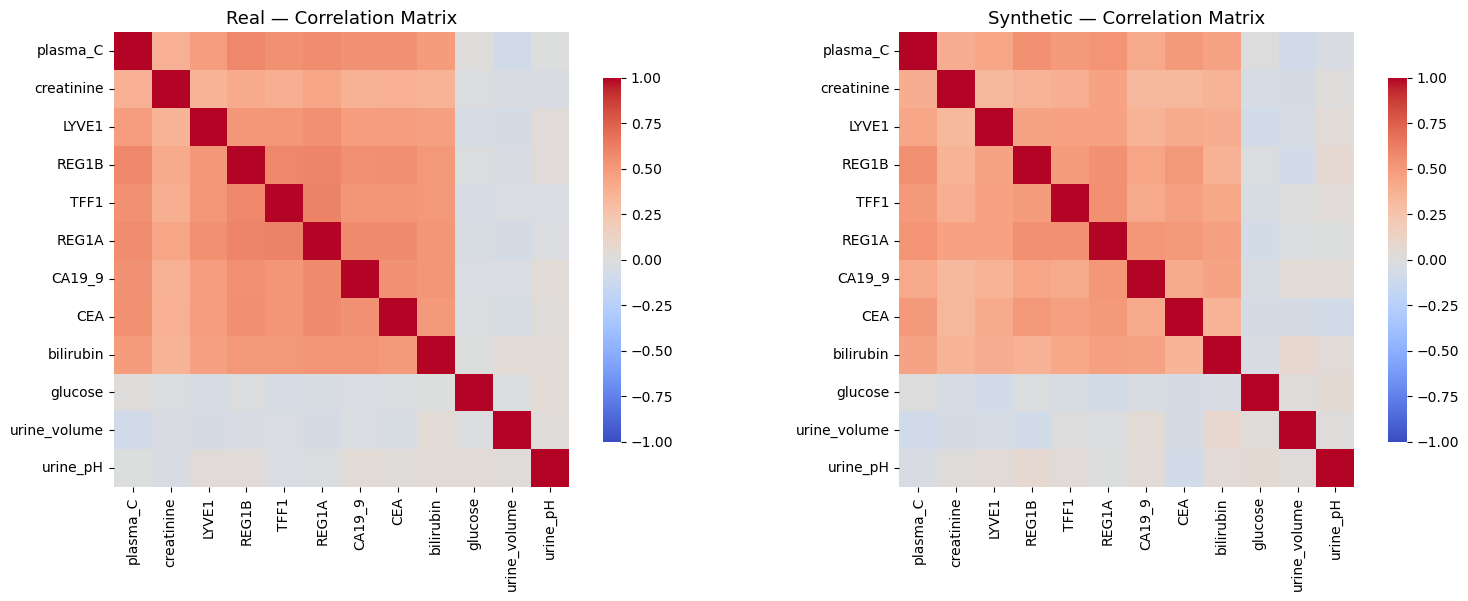

In [28]:
#Correlation matrix comparison 
r_corr = real[CONTINUOUS_COLS].corr()
s_corr = synth[CONTINUOUS_COLS].corr()
frob = np.linalg.norm(r_corr.values - s_corr.values)
print(f"Frobenius norm of correlation difference: {frob:.4f}  (lower = better)")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, corr, title in zip(axes, [r_corr, s_corr], ["Real", "Synthetic"]):
    sns.heatmap(corr, ax=ax, cmap="coolwarm", vmin=-1, vmax=1,
                annot=False, square=True, cbar_kws={"shrink": 0.8})
    ax.set_title(f"{title} — Correlation Matrix", fontsize=13)
plt.tight_layout()
plt.show()

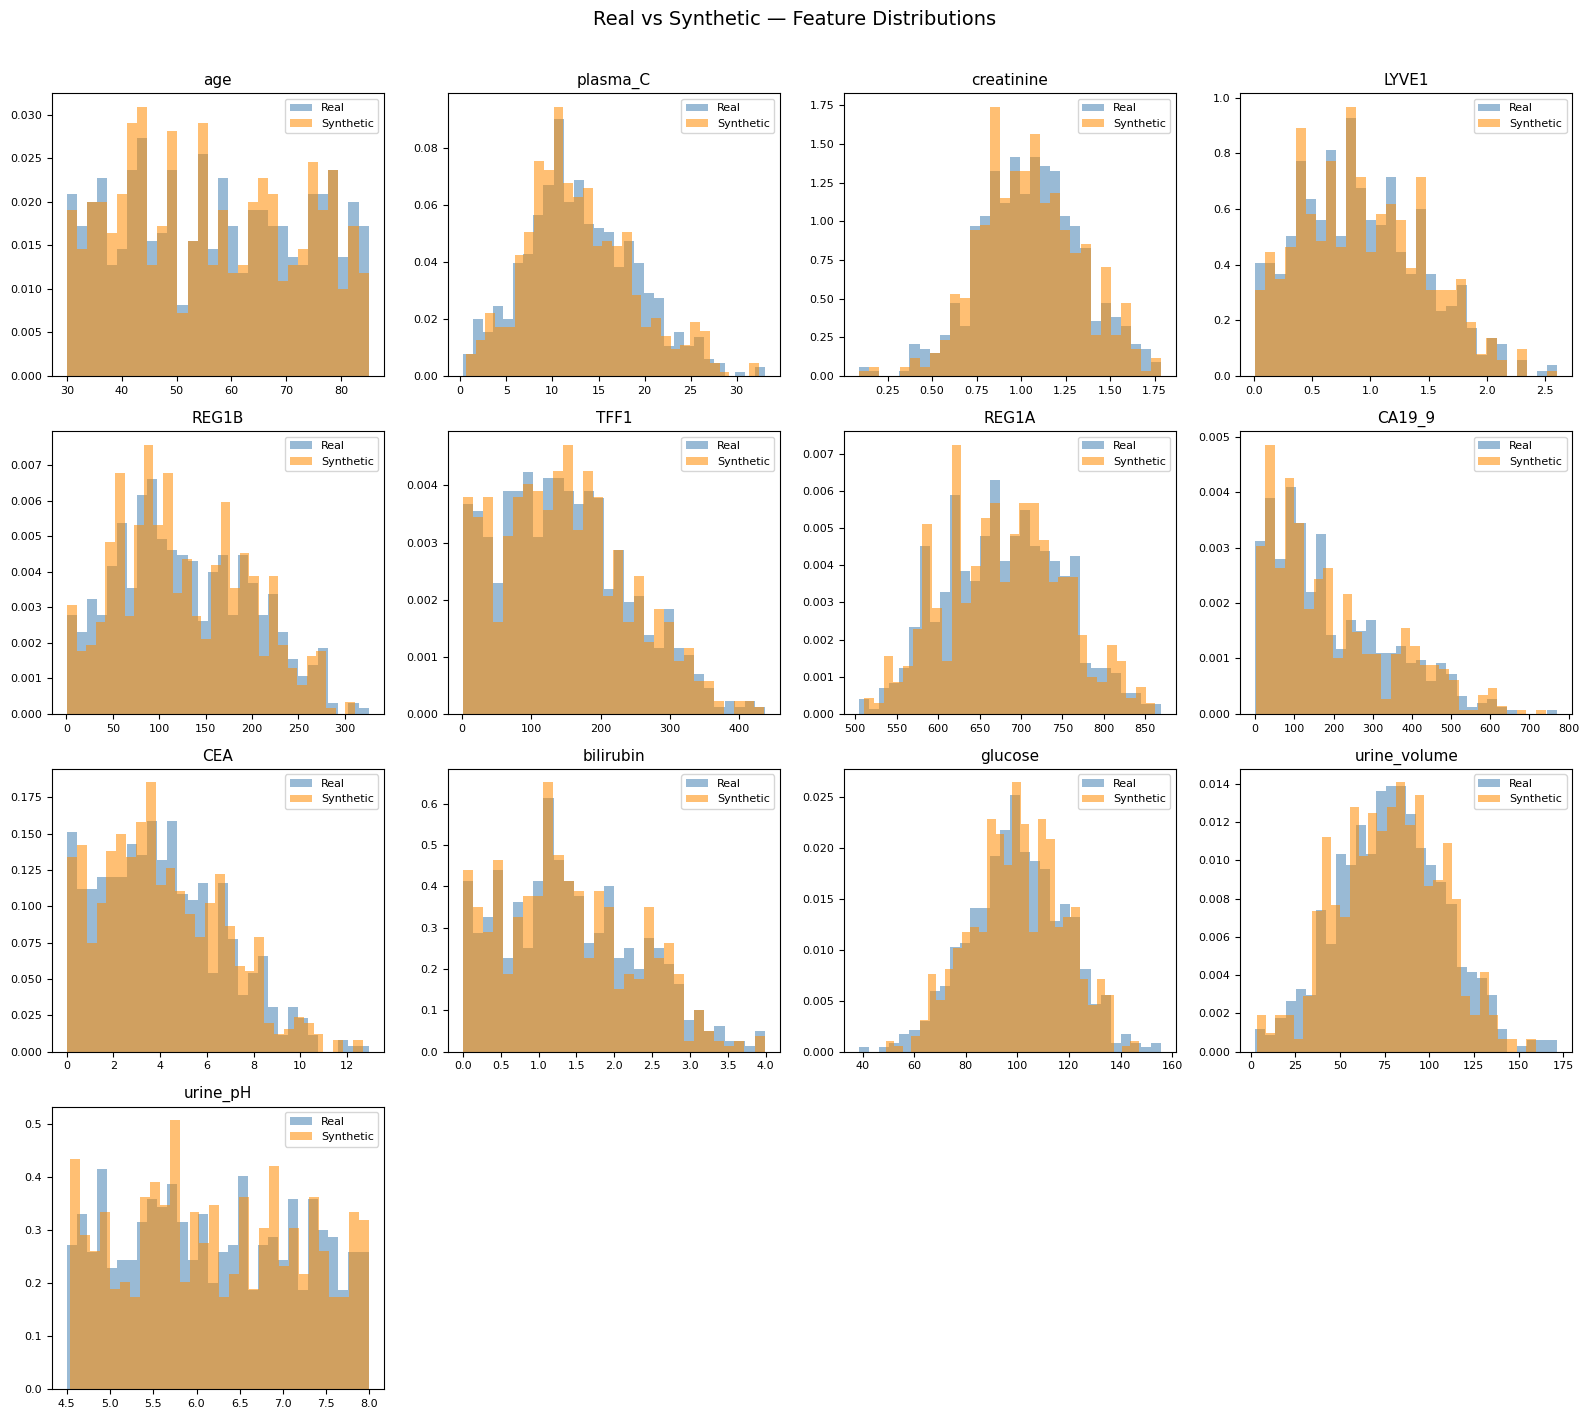

In [30]:
#Distribution plots for continuous features
cols_to_plot = [AGE_COL] + CONTINUOUS_COLS
n_cols_plot = 4
n_rows_plot = -(-len(cols_to_plot) // n_cols_plot)  

fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                         figsize=(16, n_rows_plot * 3.5))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    ax = axes[i]
    ax.hist(real[col],  bins=30, alpha=0.55, label="Real",      color="steelblue",  density=True)
    ax.hist(synth[col], bins=30, alpha=0.55, label="Synthetic", color="darkorange", density=True)
    ax.set_title(col, fontsize=11)
    ax.legend(fontsize=8)
    ax.set_xlabel("")
    ax.tick_params(labelsize=8)


for j in range(len(cols_to_plot), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Real vs Synthetic — Feature Distributions", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

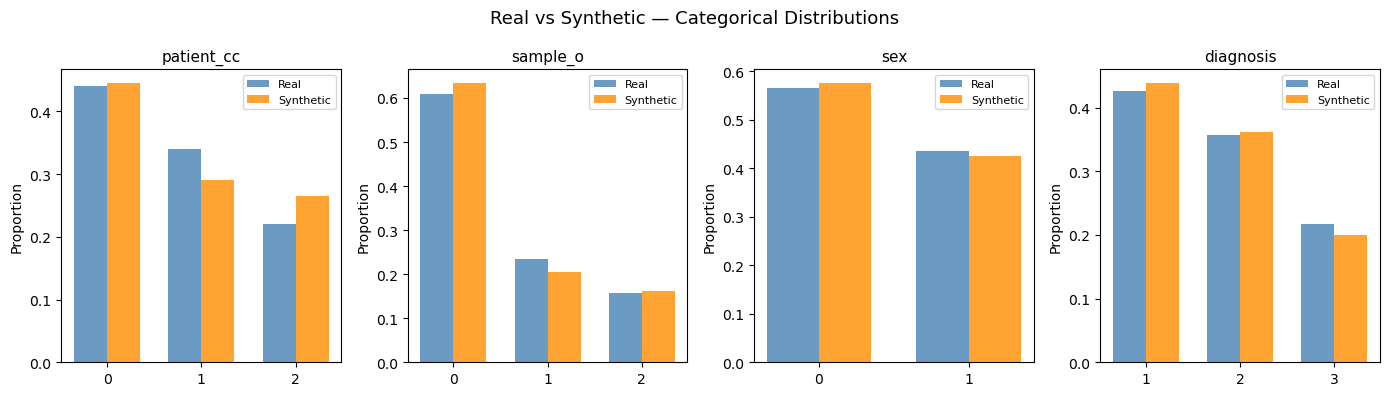

In [32]:
#Categorical bar charts 
fig, axes = plt.subplots(1, len(CATEGORICAL_COLS), figsize=(14, 4))
for ax, col in zip(axes, CATEGORICAL_COLS):
    r = real[col].value_counts(normalize=True).sort_index()
    s = synth[col].value_counts(normalize=True).sort_index()
    x = np.arange(len(r))
    w = 0.35
    ax.bar(x - w/2, r.values, w, label="Real",      color="steelblue",  alpha=0.8)
    ax.bar(x + w/2, s.values, w, label="Synthetic", color="darkorange", alpha=0.8)
    ax.set_title(col, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels([str(int(v)) for v in r.index])
    ax.set_ylabel("Proportion")
    ax.legend(fontsize=8)

fig.suptitle("Real vs Synthetic — Categorical Distributions", fontsize=13)
plt.tight_layout()
plt.show()

In [34]:
synth.to_csv(OUTPUT_PATH, index=False)
print(f"Synthetic dataset saved to: {OUTPUT_PATH}")
print(f"Shape: {synth.shape}")

Synthetic dataset saved to: ../data/synthetic_dataset3.csv
Shape: (600, 17)
